In [1]:
import sys
sys.path.append("../src")
from connect_db import get_engine

Connected successfully!


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
engine = get_engine()

# Delivery Analysis 

In [4]:
delivery_df = pd.read_sql(
    "SELECT * FROM vw_delivery_analysis",
    engine
)

In [5]:
delivery_df.head()

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-18,2017-10-10 21:25:13,8,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-13,2018-08-07 15:27:45,14,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-09-04,2018-08-17 18:06:29,9,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-15,2017-12-02 00:28:42,14,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-26,2018-02-16 18:17:02,3,0


In [6]:
delivery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96476 entries, 0 to 96475
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   order_purchase_timestamp       96476 non-null  datetime64[ns]
 2   order_estimated_delivery_date  96476 non-null  datetime64[ns]
 3   order_delivered_customer_date  96476 non-null  datetime64[ns]
 4   delivery_days                  96476 non-null  int64         
 5   is_late                        96476 non-null  int64         
dtypes: datetime64[ns](3), int64(2), object(1)
memory usage: 4.4+ MB


In [7]:
delivery_df.shape

(96476, 6)

In [8]:
avg_delivery_time = delivery_df["delivery_days"].mean()
print(f"Average Delivery Time: {avg_delivery_time:.2f} days")

Average Delivery Time: 12.50 days


In [9]:
median_delivery_time = delivery_df["delivery_days"].median()
print(f"Median Delivery Time: {median_delivery_time:.2f} days")

Median Delivery Time: 10.00 days


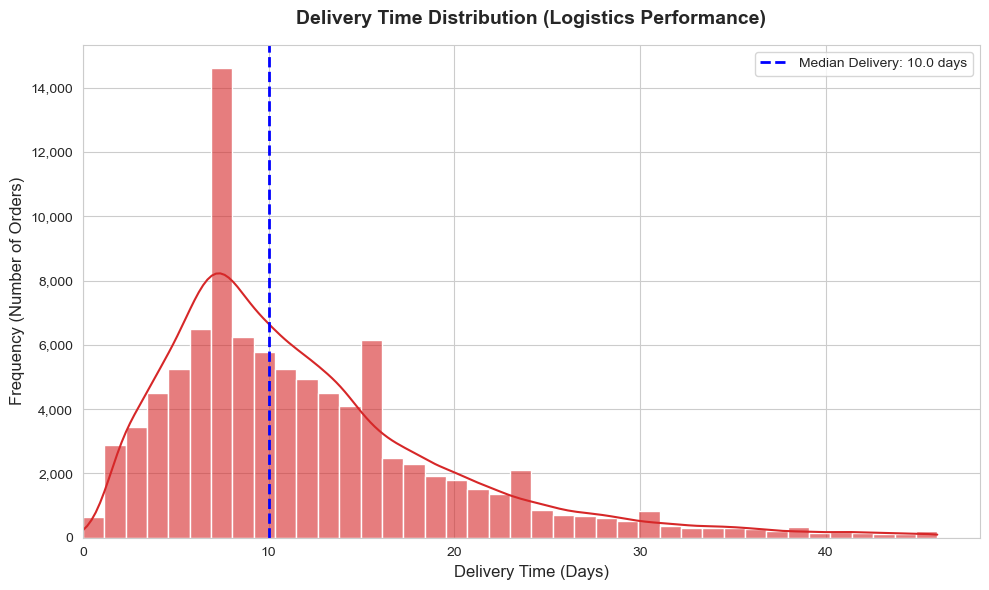

In [15]:
limit_days = delivery_df["delivery_days"].quantile(0.99)
filtered_df = delivery_df[delivery_df["delivery_days"] <= limit_days]
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=filtered_df,
    x="delivery_days",
    bins=40,
    kde=True,
    color="#d62728",
    alpha=0.6
)
plt.ticklabel_format(style='plain', axis='both')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
median_days = delivery_df["delivery_days"].median()
plt.axvline(median_days, color='blue', linestyle='--', linewidth=2, 
            label=f'Median Delivery: {median_days:.1f} days')
plt.title("Delivery Time Distribution (Logistics Performance)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Frequency (Number of Orders)", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.xlim(0, filtered_df['delivery_days'].max() * 1.05)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Phân bổ Thời gian Giao hàng (Delivery Time Distribution - Logistics Performance)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột tần suất (Histogram) kết hợp đường ước lượng mật độ nhân (KDE line) nhằm thể hiện mật độ phân phối liên tục.
* **Tiêu đề:** Delivery Time Distribution (Logistics Performance) - Phân bổ thời gian giao hàng (Hiệu suất Logistics).
* **Trục hoành (X-axis):** Delivery Time (Days) - Thời gian giao hàng tính bằng ngày (kéo dài từ 0 đến hơn 45 ngày).
* **Trục tung (Y-axis):** Frequency (Number of Orders) - Tần suất xuất hiện tính bằng số lượng đơn hàng (dao động từ mốc 0 đến hơn 14,000 đơn).
* **Đường chỉ số đặc biệt:** Đường nét đứt màu xanh dương thể hiện giá trị trung vị (Median Delivery) ở mốc **10.0 ngày**.

---

## 2. Các Quan sát Thống kê từ Biểu đồ

* **Cột tần suất cao nhất (Chạm đỉnh đồ thị):** Nằm ở khung khoảng **7 - 8 ngày** với số lượng đơn hàng vượt mốc **14,000 đơn**. Đây là khoảng thời gian giao hàng phổ biến nhất (Mode) của hệ thống logistics này.
* **Vị trí đường Trung vị (Median):** Đường nét đứt màu xanh cắt chính xác tại mốc **10.0 ngày**. Điều này có nghĩa là 50% tổng số đơn hàng được giao thành công trong vòng dưới 10 ngày, và 50% số đơn hàng còn lại mất nhiều hơn 10 ngày để đến tay người nhận.
* **Các điểm nhô cao bất thường (Minor Peaks):** Ngoài đỉnh chính ở ngày 7-8, đồ thị còn xuất hiện hai cột nhô cao rõ rệt ở mốc **15 ngày** (~6,000 đơn) và **24 ngày** (~2,000 đơn). Điều này thường do các đơn hàng rơi vào các mốc thời gian cố định như giao hàng liên vùng hoặc đơn bị lưu kho định kỳ tại trạm trung chuyển.

---

## 3. Nhận xét và Đánh giá Hình dạng Phân phối (Insights)

* **Phân phối lệch phải có độ dốc dài (Right-Skewed / Long-Tailed Distribution):**
  * Đồ thị có phần đuôi (tail) kéo dài rất sâu về phía bên phải, kéo dài từ ngày 20 đến tận hơn 45 ngày. 
  * **Đánh giá hiệu suất vận hành:** Mặc dù phần lớn đơn hàng được xử lý tốt và giao trong khoảng 5 - 15 ngày, nhưng phần đuôi dài chứng tỏ hệ thống đang gặp vấn đề kiểm soát đối với nhóm đơn hàng bị trễ hạn (Delayed orders). Những đơn hàng mất từ 30 đến 45 ngày mới giao tới nơi chính là điểm nghẽn (bottleneck) gây ảnh hưởng nghiêm trọng đến trải nghiệm và mức độ hài lòng của khách hàng (Customer Satisfaction).
  * Với kiểu phân phối lệch phải này, giá trị thời gian giao hàng trung bình (Mean) chắc chắn sẽ bị kéo lên cao hơn mốc trung vị 10 ngày do chịu ảnh hưởng từ những đơn hàng bị giao siêu trễ phía cuối đồ thị.

In [17]:
late_orders = delivery_df["is_late"].sum()
total_orders = len(delivery_df)
late_percentage = ( late_orders/total_orders) * 100
print( f"Late Delivery Rate: {late_percentage:.2f}%")

Late Delivery Rate: 8.11%


In [ ]:
late_summary = (delivery_df["is_late"].value_counts().reset_index())
late_summary.columns = ["is_late","count"]

In [ ]:
late_summary["status"] = (late_summary["is_late"].map({0: "On Time",1: "Late"}))

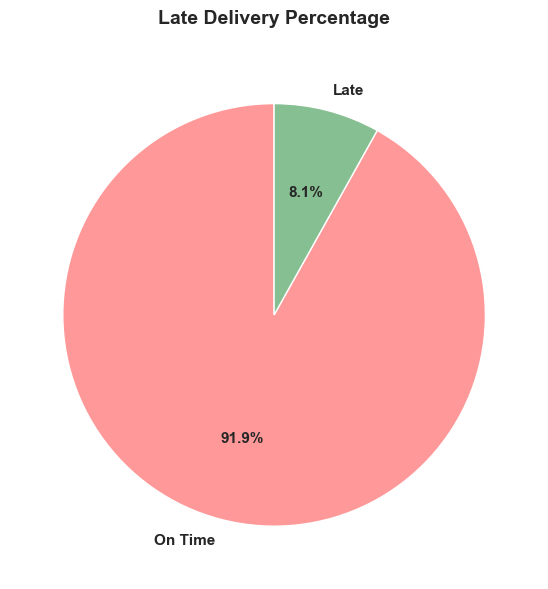

In [22]:
colors = ['#ff9999', '#86bf91', '#aec7e8', '#ffbb78']
plt.figure(figsize=(6, 6))
plt.pie(
    late_summary["count"],
    labels=late_summary["status"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors[:len(late_summary)],
    textprops={'fontsize': 11, 'weight': 'bold'}
)
plt.title("Late Delivery Percentage", fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Tỷ lệ Giao hàng Trễ hạn (Late Delivery Percentage)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python tính toán dựa trên cột bô-lean/số nguyên `is_late` trong DataFrame `delivery_df` để xác định tỷ lệ phần trăm trễ hạn tổng thể. Tiếp theo, sử dụng hàm `.value_counts()` và mã hóa nhãn (`0: "On Time"`, `1: "Late"`) để chuẩn bị dữ liệu vẽ hình.
* **Loại biểu đồ:** Biểu đồ tròn (Pie chart) hiển thị tỷ lệ phần trăm trực quan cho từng trạng thái giao hàng.
* **Tiêu đề:** Late Delivery Percentage (Tỷ lệ phần trăm giao hàng trễ).

---

## 2. Số liệu Chi tiết từ Mã nguồn và Biểu đồ
Kết quả tính toán logic và hiển thị trực quan ghi nhận các chỉ số chính xác như sau:
* **Late Delivery Rate (Tỷ lệ trễ hạn chính xác từ console):** **8.11%** (Biểu đồ tròn làm tròn hiển thị: **8.1%**, tương ứng với phần quạt màu xanh lá).
* **On Time Rate (Tỷ lệ đúng hạn):** **91.89%** (Biểu đồ tròn làm tròn hiển thị: **91.9%**, tương ứng với phần quạt màu đỏ/hồng chiếm đa số).

---

## 3. Nhận xét và Đánh giá (Insights)

* **Hiệu suất Logistics ở mức khá tốt nhưng vẫn còn dư địa cải thiện:**
  * Hệ thống ghi nhận tỷ lệ giao hàng đúng hạn rất cao, đạt **91.9%**. Phần lớn đơn hàng đã tuân thủ đúng cam kết thời gian quy định, tạo nền tảng tin cậy cho dịch vụ khách hàng.
  * Tuy nhiên, tỷ lệ trễ hạn **8.11%** (khoảng 8 đơn hàng bị trễ trên mỗi 100 đơn phát đi) vẫn là một con số cần lưu tâm đối với một hệ thống vận hành chuyên nghiệp. 

* **Mối liên hệ với phân bổ phân phối trước đó:**
  * Chỉ số 8.11% này chính là lời giải thích định lượng cho phần "đuôi dài lệch phải" (Long tail) kéo dài từ 20 đến hơn 45 ngày ở biểu đồ *Delivery Time Distribution* trước đó. Nhóm 8.11% đơn hàng bị dán nhãn `Late` này chính là tác nhân trực tiếp làm giảm điểm trải nghiệm người dùng, cần được bóc tách sâu hơn theo vùng địa lý hoặc đơn vị vận chuyển để tìm ra nguyên nhân cốt lõi.

---



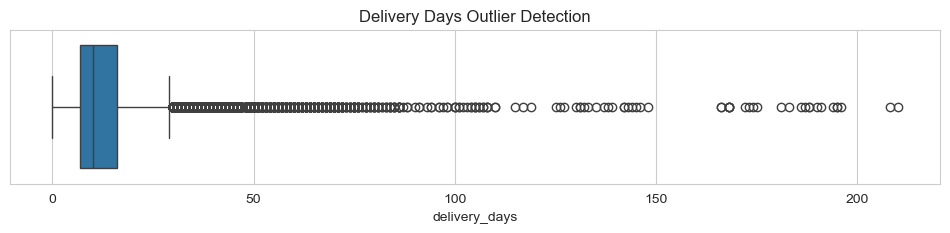

In [ ]:
plt.figure(figsize=(12,2))
sns.boxplot(
    x=delivery_df["delivery_days"]
)
plt.title(
    "Delivery Days Outlier Detection"
)
plt.show()

In [29]:
Q1 = delivery_df[ "delivery_days"].quantile(0.25)
Q3 = delivery_df["delivery_days"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = ( Q1 - 1.5 * IQR)
upper_bound = ( Q3 + 1.5 * IQR)
delivery_outliers = delivery_df[(delivery_df["delivery_days"] < lower_bound) |( delivery_df["delivery_days"] > upper_bound)]

In [30]:
print(f"Number of Outliers: {len(delivery_outliers):,}")

Number of Outliers: 4,732


In [31]:
print(f"Outlier Percentage: {len(delivery_outliers)/len(delivery_df)*100:.2f}%")

Outlier Percentage: 4.90%


In [32]:
delivery_df["delivery_group"] = pd.cut(
    delivery_df["delivery_days"],
    bins=[0, 7,14,21,30,999],
    labels=["0-7 Days","8-14 Days","15-21 Days","22-30 Days",">30 Days"]
)

In [33]:
delivery_group = (delivery_df["delivery_group"] .value_counts() .sort_index())

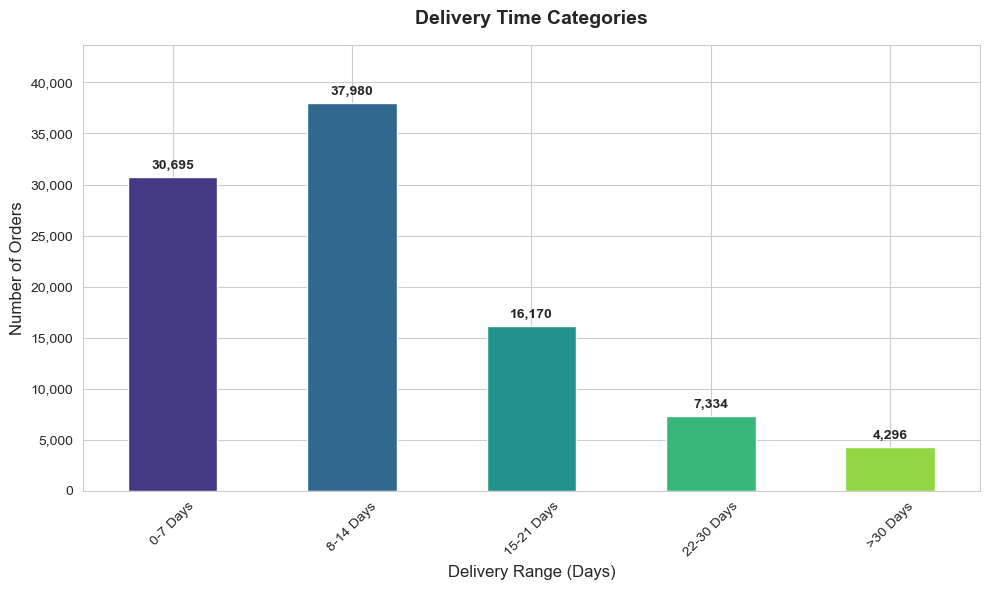

In [34]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(delivery_group))
ax = delivery_group.plot(kind="bar", color=colors, rot=45)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Delivery Time Categories", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Delivery Range (Days)", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.ylim(0, delivery_group.max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Phân nhóm Thời gian Giao hàng (Delivery Time Categories)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python tiến hành rời rạc hóa (Binning) biến liên tục `delivery_days` bằng hàm `pd.cut()`. Dữ liệu được chia thành 5 khoảng (bins) cố định: `[0, 7, 14, 21, 30, 999]` với các nhãn tương ứng. Sau đó dùng `.value_counts().sort_index()` để thống kê số lượng đơn hàng theo đúng thứ tự phân lớp.
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) có hiển thị nhãn giá trị số lượng đơn hàng chính xác trên đầu mỗi cột.
* **Tiêu đề:** Delivery Time Categories (Các nhóm thời gian giao hàng).
* **Trục tung (Y-axis):** Number of Orders - Số lượng đơn hàng (dao động từ mốc 0 đến 40,000 đơn).
* **Trục hoành (X-axis):** Delivery Range (Days) - Khung thời gian giao hàng đã được phân lớp.

---

## 2. Số liệu Chi tiết từ Biểu đồ
Hệ thống ghi nhận số lượng đơn hàng chính xác rơi vào từng nhóm thời gian như sau:
* **0-7 Days (Dưới 1 tuần):** 30,695 đơn hàng
* **8-14 Days (Từ 1 đến 2 tuần):** 37,980 đơn hàng *(Nhóm chiếm đa số)*
* **15-21 Days (Từ 2 đến 3 tuần):** 16,170 đơn hàng
* **22-30 Days (Từ 3 tuần đến 1 tháng):** 7,334 đơn hàng
* **>30 Days (Trên 1 tháng):** 4,296 đơn hàng

---

## 3. Nhận xét và Đánh giá (Insights)

* **Năng lực xử lý chính nằm trong khoảng 2 tuần đầu (Khung tối ưu):**
  * Hai nhóm **0-7 Days** (30,695 đơn) và **8-14 Days** (37,980 đơn) chiếm tỷ trọng áp đảo hoàn toàn trên biểu đồ. 
  * Điều này cho thấy phần lớn đơn hàng của doanh nghiệp (hơn 68,000 đơn) được xử lý và giao thành công tới tay khách hàng rất nhanh chóng, chỉ trong vòng 2 tuần đổ lại. Khung **8-14 Days** chính là điểm rơi phổ biến nhất của hệ thống giao vận hiện tại.

* **Diện mạo rõ ràng của nhóm giao hàng trễ hạn (>22 ngày):**
  * Biểu đồ phân lớp này đã giúp làm rõ nét hơn con số 8.11% đơn hàng trễ thu được từ phân tích trước đó. 
  * Nhóm đơn hàng có thời gian vận chuyển kéo dài từ 3 tuần cho đến hơn 1 tháng chiếm số lượng đáng kể: **7,334 đơn** (khung 22-30 ngày) và **4,296 đơn** (khung trên 30 ngày). Hơn 4,000 đơn hàng phải mất trên 1 tháng mới hoàn thành chính là nhóm rủi ro cao nhất, gây ảnh hưởng tiêu cực đến dịch vụ chăm sóc khách hàng và cần có biện pháp tối ưu tuyến đường hoặc đổi đơn vị vận chuyển đối với các khu vực này.

---



C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_22056\1509782847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


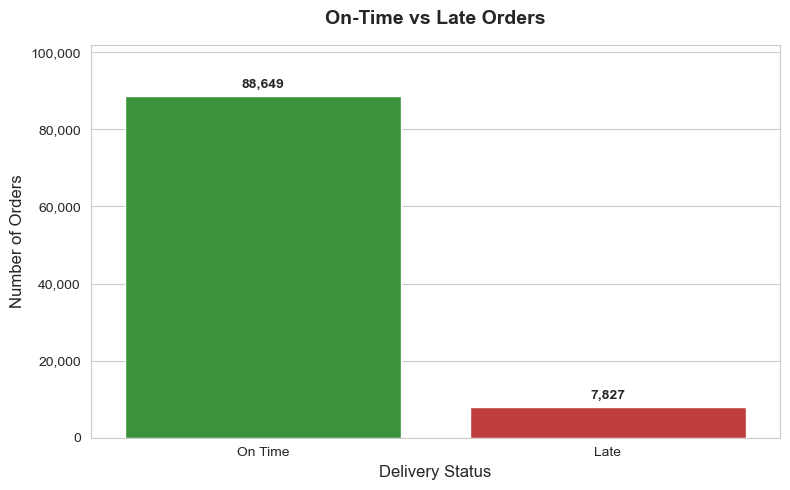

In [35]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=delivery_df,
    x="is_late",
    palette=["#2ca02c", "#d62728"]
)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.xticks(ticks=[0, 1], labels=["On Time", "Late"])
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("On-Time vs Late Orders", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Delivery Status", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.ylim(0, delivery_df["is_late"].value_counts().max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Trạng thái Đơn hàng Đúng hạn và Trễ hạn (On-Time vs Late Orders)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) có hiển thị nhãn giá trị số lượng đơn hàng chính xác trên đầu mỗi cột.
* **Tiêu đề:** On-Time vs Late Orders (Đơn hàng đúng hạn so với trễ hạn).
* **Trục tung (Y-axis):** Number of Orders - Số lượng đơn hàng (dao động từ mốc 0 đến 100,000 đơn).
* **Trục hoành (X-axis):** Delivery Status - Trạng thái giao hàng (On Time, Late).

---

## 2. Số liệu Chi tiết từ Biểu đồ
Biểu đồ hiển thị chính xác số lượng đơn hàng của từng trạng thái giao vận như sau:
* **On Time (Đúng hạn):** 88,649 đơn hàng.
* **Late (Trễ hạn):** 7,827 đơn hàng.

---

## 3. Nhận xét và Đánh giá (Insights)

* **Năng lực đáp ứng dịch vụ duy trì ở mức cao:**
  * Khối lượng đơn hàng giao đúng hạn chiếm tỷ trọng áp đảo tuyệt đối với **88,649 đơn**, chứng tỏ luồng xử lý và vận chuyển chính của doanh nghiệp đang hoạt động rất trơn tru và hiệu quả.

* **Kiểm soát rủi ro từ nhóm trễ hạn:**
  * Nhóm đơn hàng bị dán nhãn trễ hạn dừng lại ở con số **7,827 đơn**. 
  * **Sự cải thiện về mặt trực quan hóa:** Khác với biểu đồ tròn (Pie chart) trước đó khi dùng màu xanh cho lệnh trễ, biểu đồ này đã chuẩn hóa lại quy ước màu sắc rất chính xác và dễ nhìn: Sử dụng **màu Xanh lá (Green) cho On Time** (Thể hiện sự an toàn/hoàn thành tốt) và **màu Đỏ (Red) cho Late** (Thể hiện sự cảnh báo/rủi ro). Cách phối màu này giúp người xem ngay lập tức nhận diện được vùng dữ liệu cần tối ưu mà không bị nhầm lẫn.